In [66]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys
import hist
import hist.intervals

sys.path.append("../analysisTools/")
import plotTools as ptools
import utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [67]:
f_sig = "../coffea/AllInOne_2022/AllInOne.coffea"

#Nested Dictionary:
sig_histo = util.load(f_sig) [0]

Saved: ./plots/signal_2018/gen_ele_vxy10_m110.png
count: [ 970.  960. 1006.  904.  736. 1274.  409.  269.  167.  112.   61.   41.
   44.]
[ 970.  960. 1006.  904.  736. 1274.  409.  269.  167.  112.   61.   41.
   44.]
TOTAL number of gen electrons: 6953.0


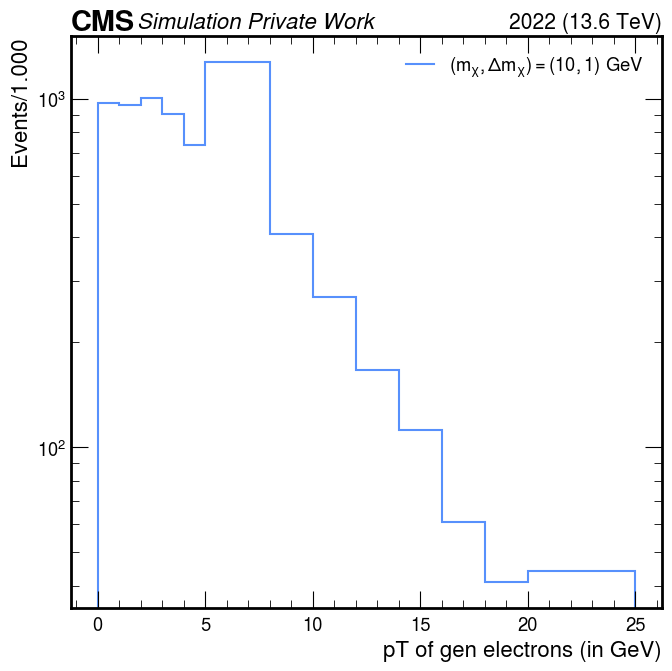

In [68]:
fig, ax = plt.subplots(figsize=(7,7))

delta =0.1
ctau =10

# Plot settings
plot_dict = {
    'variable':'gen_ele_pt',
    'cut': 'cut3',
    'year': 2022
}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': False,
    'doYerr': False, 
    'xlabel': "pT of gen electrons (in GeV)",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'gen_ele_vxy10_m110.png'
}



#signal points
m1=10
delta =0.1
ctau =10

counts, edges = ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)
print ("count:", counts)

mask = counts != 0

bins_x = (edges[:-1] + edges[1:])*(0.5)

counts_nonzero_den = np.where(mask, counts, np.nan)
edges_nonzero_den  = np.where(mask, bins_x, np.nan)

print (counts_nonzero_den)

total = np.sum(counts_nonzero_den)
print ("TOTAL number of gen electrons:", total)


Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
TOTAL number of low-pT electrons (Xclean case): 2670.0
Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
TOTAL number of low-pT electrons (No xclean case): 3341.0


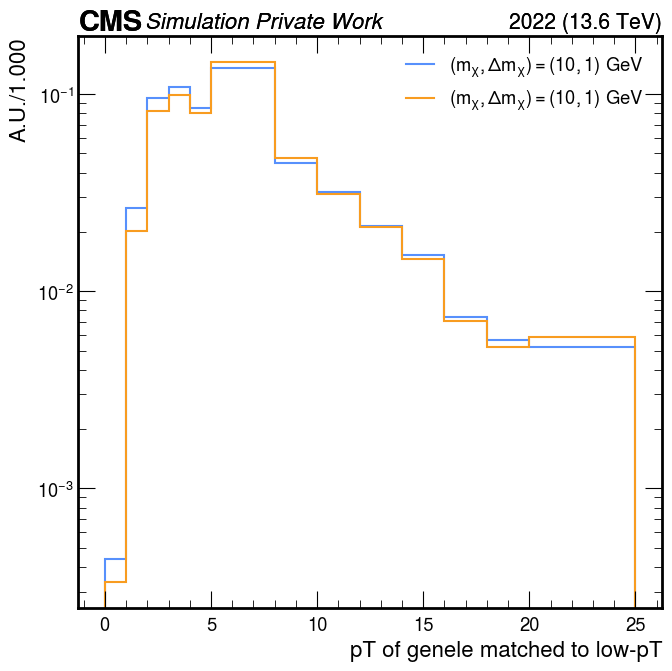

In [69]:
fig, ax = plt.subplots(figsize=(7,7))

plot_dict = {'variable': 'pT_genElePos_Lpt', 'cut': 'cut3', 'year': 2022}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': True,
    'doYerr': False, 
    #'xlabel': "pT of gen electrons(matched to 'R')",  
    'xlabel': "pT of genele matched to low-pT",              # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None  ,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'match_ele_gen_vxy10_m110.png'
}
m1=10
delta = 0.1
ctau = 10

counts_xcleaned, edges_xcleaned = ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)



bins_x_xcleaned = (edges_xcleaned[:-1] + edges_xcleaned[ 1:])*(0.5)

total_xcleaned = np.sum(counts_xcleaned)
print ("TOTAL number of low-pT electrons (Xclean case):", total_xcleaned)






plot_dict = {'variable': 'pT_genElePos_Lpt_Noxclean', 'cut': 'cut3', 'year': 2022}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': True,
    'doYerr': False, 
    #'xlabel': "pT of gen electrons(matched to 'R')",  
    'xlabel': "pT of genele matched to low-pT",              # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None  ,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'match_ele_gen_vxy10_m110.png'
}
m1=10
delta = 0.1
ctau = 10

counts_noxclean, edges_noxclean = ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)



bins_x_noxclean = (edges_noxclean[:-1] + edges_noxclean[ 1:])*(0.5)

total_noxclean = np.sum(counts_noxclean)
print ("TOTAL number of low-pT electrons (No xclean case):", total_noxclean)




Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
TOTAL number of gen electrons matched as GED: 730.0


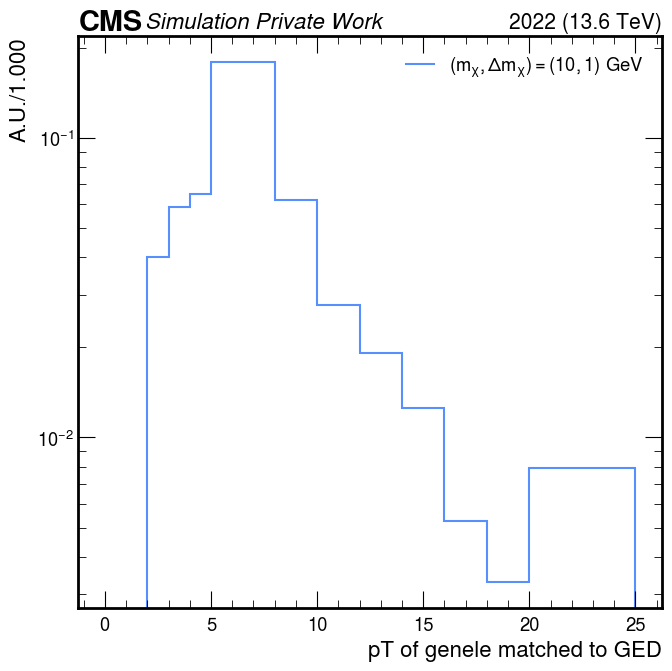

In [70]:
fig, ax = plt.subplots(figsize=(7,7))



plot_dict = {'variable': 'pT_genElePos_GED', 'cut': 'cut3', 'year': 2022}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': True,
    'doYerr': False, 
    #'xlabel': "pT of gen electrons(matched to 'R')",  
    'xlabel': "pT of genele matched to GED",              # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None  ,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'match_ele_gen_vxy10_m110.png'
}
m1=10
delta = 0.1
ctau = 10

counts_GED, edges_GED = ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)

bins_x_GED = (edges_GED[:-1] + edges_GED[ 1:])*(0.5)

total_GED = np.sum(counts_GED)
print ("TOTAL number of gen electrons matched as GED:", total_GED)





In [71]:
def eff_determine_unc(n, d):
    eff = np.divide(n, d)
    unc = hist.intervals.ratio_uncertainty(n, d, 'efficiency')
    return eff, unc


efficiency_noxclean, unc_eff_noxclean = eff_determine_unc(counts_noxclean, counts_nonzero_den)
print ("efficiency_noxclean:",efficiency_noxclean)

efficiency_xcleaned, unc_eff_xcleaned = eff_determine_unc(counts_xcleaned, counts_nonzero_den)
print ("efficiency_xcleaned:",efficiency_xcleaned)

efficiency_GED, unc_eff_GED = eff_determine_unc(counts_GED, counts_nonzero_den)
print ("efficiency_GED:",efficiency_GED)

efficiency_noxclean: [0.00206186 0.12604167 0.48906561 0.65044248 0.65217391 0.68210361
 0.69193154 0.68773234 0.75449102 0.77678571 0.68852459 0.75609756
 0.79545455]
efficiency_xcleaned: [0.00206186 0.12604167 0.43538767 0.55199115 0.52853261 0.48587127
 0.49877751 0.54275093 0.58682635 0.625      0.55737705 0.63414634
 0.54545455]
efficiency_GED: [0.         0.         0.06063618 0.09845133 0.13451087 0.21350078
 0.22982885 0.15613383 0.17365269 0.16964286 0.13114754 0.12195122
 0.27272727]


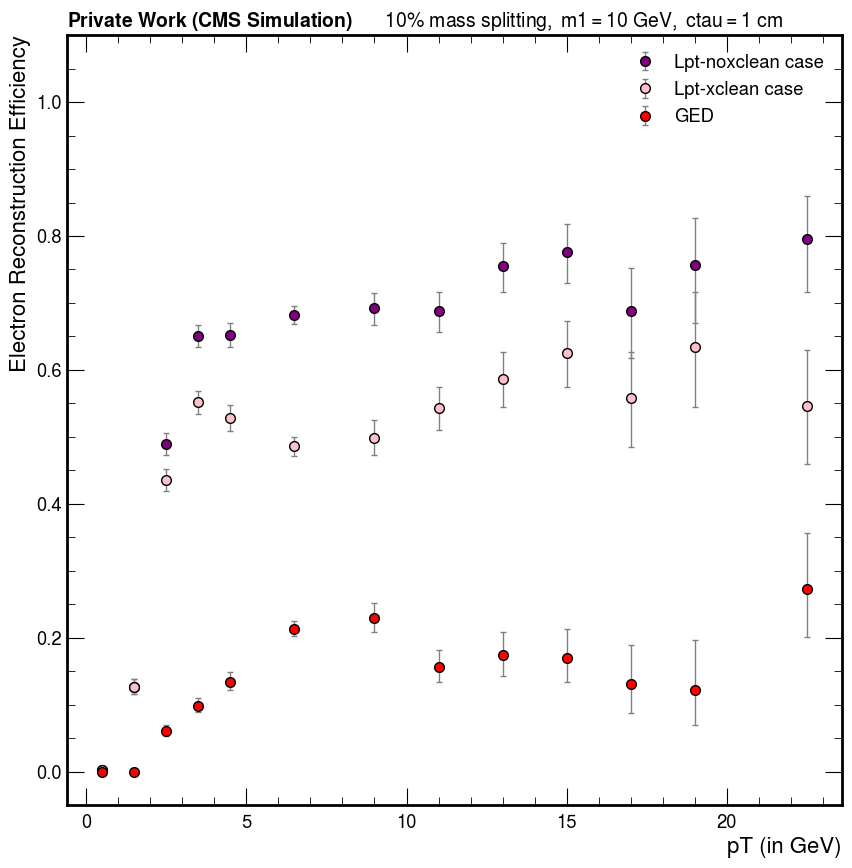

In [77]:
plt.errorbar(
    bins_x_noxclean, efficiency_noxclean,
    yerr=unc_eff_noxclean ,fmt='o', markersize=7, markerfacecolor='purple', markeredgecolor='black',
    ecolor='gray', elinewidth=1, capsize=2,
    label='Lpt-noxclean case'  
)

plt.errorbar(
    bins_x_xcleaned, efficiency_xcleaned,
    yerr=unc_eff_xcleaned ,fmt='o', markersize=7, markerfacecolor='pink', markeredgecolor='black',
    ecolor='gray', elinewidth=1, capsize=2,
    label='Lpt-xclean case'
)

plt.errorbar(
    bins_x_GED, efficiency_GED,
    yerr=unc_eff_GED ,fmt='o', markersize=7, markerfacecolor='red', markeredgecolor='black',
    ecolor='gray', elinewidth=1, capsize=2,
    label='GED'  
)



# plt.xlim(0,30)
plt.ylim(-0.05,1.1)
plt.xlabel("pT (in GeV)")
# plt.ylabel("Efficiency of the GED algorithm")
plt.ylabel("Electron Reconstruction Efficiency")

plt.title(r"$\bf{Private\ Work\ (CMS\ Simulation)} \qquad \mathrm{10\% \ mass\ splitting, \ m1 = 10\ GeV, \ ctau = 1\ cm}$",
          fontsize=14, loc='left')

# plt.title("Gen Lxy < 1cm")
plt.legend(loc='upper right')
plt.savefig("L_lxy_ERE.png", dpi=300)

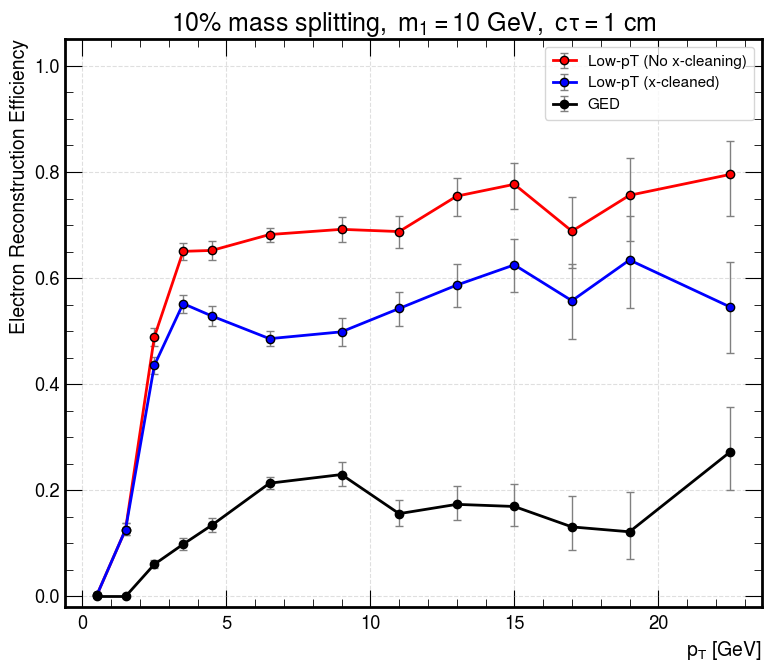

In [99]:
plt.figure(figsize=(8,7))

plt.errorbar(
    bins_x_noxclean,
    efficiency_noxclean,
    yerr=unc_eff_noxclean,
    fmt='o-',
    linewidth=2,
    markersize=6,
    color='red',
    markeredgecolor='black',
    ecolor='gray',
    elinewidth=1,
    capsize=3,
    label='Low-pT (No x-cleaning)'
)

plt.errorbar(
    bins_x_xcleaned,
    efficiency_xcleaned,
    yerr=unc_eff_xcleaned,
    fmt='o-',
    linewidth=2,
    markersize=6,
    color='blue',
    markeredgecolor='black',
    ecolor='gray',
    elinewidth=1,
    capsize=3,
    label='Low-pT (x-cleaned)'
)

plt.errorbar(
    bins_x_GED,
    efficiency_GED,
    yerr=unc_eff_GED,
    fmt='o-',
    linewidth=2,
    markersize=6,
    color='black',
    markeredgecolor='black',
    ecolor='gray',
    elinewidth=1,
    capsize=3,
    label='GED'
)

# Axis styling
plt.ylim(-0.02, 1.05)
plt.xlabel(r"$p_T$ [GeV]", fontsize=14)
plt.ylabel("Electron Reconstruction Efficiency", fontsize=14)



# Grid helps readability
plt.grid(True, linestyle='--', alpha=0.4)

# Better title formatting


plt.title(
    
    r"$10\%\ \mathrm{mass\ splitting},\ m_1 = 10\ \mathrm{GeV},\ c\tau = 1\ \mathrm{cm}$",
    fontsize=18
)



plt.legend(fontsize=11, frameon=True, loc='upper right')

plt.tight_layout()

plt.savefig("L_lxy_ERE.png", dpi=300)